# Rates Analytics Demo

This notebook demonstrates a simple fixed income analytics workflow:

- discount factor calculation
- zero rate conversion
- bond pricing
- DV01 sensitivity analysis
- price/yield visualization

The goal is to show a clean, practical implementation of pricing and risk concepts commonly used in rates analytics.

In [10]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Make sure the notebook can import from ../src
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

In [12]:
# Fallback implementations in case the src files are not ready yet.
# Once your src modules are implemented, you can replace these imports accordingly.

def discount_factor(rate: float, t: float) -> float:
    """
    Compute discount factor assuming continuous compounding.
    """
    if t < 0:
        raise ValueError("Time t must be non-negative.")
    return float(np.exp(-rate * t))


def zero_rate(df: float, t: float) -> float:
    """
    Convert discount factor to zero rate under continuous compounding.
    """
    if t <= 0:
        raise ValueError("Time t must be positive.")
    if df <= 0:
        raise ValueError("Discount factor must be positive.")
    return float(-np.log(df) / t)


def bond_price(
    face: float,
    coupon_rate: float,
    maturity: int,
    yield_rate: float,
    freq: int = 1
) -> float:
    """
    Price a plain fixed-rate bond using discrete compounding.

    Parameters
    ----------
    face : float
        Face value of the bond.
    coupon_rate : float
        Annual coupon rate, e.g. 0.05 for 5%.
    maturity : int
        Maturity in years.
    yield_rate : float
        Annual yield to maturity.
    freq : int
        Coupon frequency per year.

    Returns
    -------
    float
        Present value of the bond.
    """
    if face <= 0:
        raise ValueError("Face value must be positive.")
    if maturity <= 0:
        raise ValueError("Maturity must be positive.")
    if freq <= 0:
        raise ValueError("Frequency must be positive.")

    n_periods = maturity * freq
    coupon = face * coupon_rate / freq
    y = yield_rate / freq

    pv_coupons = sum(coupon / ((1 + y) ** t) for t in range(1, n_periods + 1))
    pv_face = face / ((1 + y) ** n_periods)
    return float(pv_coupons + pv_face)


def bond_dv01(
    face: float,
    coupon_rate: float,
    maturity: int,
    yield_rate: float,
    freq: int = 1,
    bump: float = 1e-4
) -> float:
    """
    Approximate DV01 using a 1 bp parallel bump in yield.

    Returns the dollar price change for a +1 bp move in yield.
    """
    base_price = bond_price(face, coupon_rate, maturity, yield_rate, freq)
    bumped_price = bond_price(face, coupon_rate, maturity, yield_rate + bump, freq)
    return float(bumped_price - base_price)

## 1. Discount factor and zero rate

A basic building block in fixed income pricing is the discount factor.  
Below we compute the discount factor for a 5% continuously compounded rate over 2 years, and recover the implied zero rate.

In [13]:
rate = 0.05
t = 2.0

df = discount_factor(rate, t)
zr = zero_rate(df, t)

print(f"Input rate       : {rate:.4%}")
print(f"Time             : {t:.2f} years")
print(f"Discount factor  : {df:.6f}")
print(f"Recovered z-rate : {zr:.4%}")

Input rate       : 5.0000%
Time             : 2.00 years
Discount factor  : 0.904837
Recovered z-rate : 5.0000%


## 2. Bond pricing example

We price a 5-year fixed-rate bond with:

- face value = 100
- coupon = 5%
- yield = 4%
- annual coupon payments

In [14]:
face = 100.0
coupon_rate = 0.05
maturity = 5
yield_rate = 0.04
freq = 1

price = bond_price(
    face=face,
    coupon_rate=coupon_rate,
    maturity=maturity,
    yield_rate=yield_rate,
    freq=freq
)

print(f"Bond price: {price:.4f}")

Bond price: 104.4518


## 3. DV01 sensitivity

DV01 measures the change in bond price for a 1 basis point increase in yield.

For a plain bond, DV01 should typically be negative because bond prices fall as yields rise.

In [15]:
dv01 = bond_dv01(
    face=face,
    coupon_rate=coupon_rate,
    maturity=maturity,
    yield_rate=yield_rate,
    freq=freq
)

print(f"DV01 (price change for +1bp in yield): {dv01:.6f}")

DV01 (price change for +1bp in yield): -0.045756


## 4. Price-yield relationship

This chart illustrates the inverse relationship between bond prices and yields.

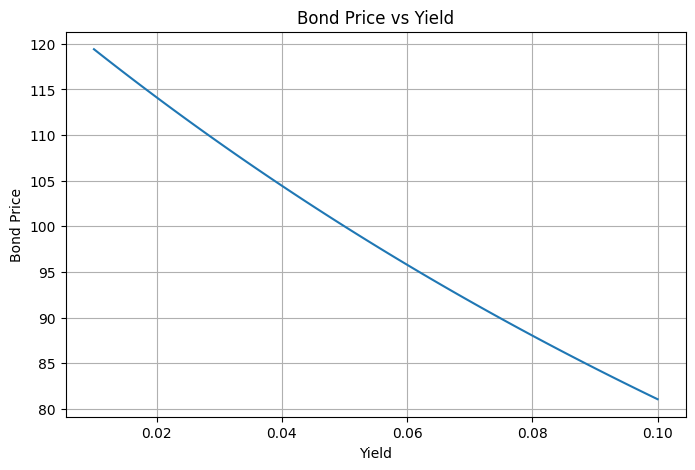

In [16]:
yields = np.linspace(0.01, 0.10, 100)
prices = [
    bond_price(
        face=face,
        coupon_rate=coupon_rate,
        maturity=maturity,
        yield_rate=y,
        freq=freq
    )
    for y in yields
]

plt.figure(figsize=(8, 5))
plt.plot(yields, prices)
plt.xlabel("Yield")
plt.ylabel("Bond Price")
plt.title("Bond Price vs Yield")
plt.grid(True)
plt.show()

## 5. Sensitivity table

Below is a small scenario table showing bond price across different yield levels.

In [17]:
scenario_yields = [0.02, 0.03, 0.04, 0.05, 0.06]
scenario_prices = [
    bond_price(
        face=face,
        coupon_rate=coupon_rate,
        maturity=maturity,
        yield_rate=y,
        freq=freq
    )
    for y in scenario_yields
]

for y, p in zip(scenario_yields, scenario_prices):
    print(f"Yield: {y:.2%} | Bond Price: {p:.4f}")

Yield: 2.00% | Bond Price: 114.1404
Yield: 3.00% | Bond Price: 109.1594
Yield: 4.00% | Bond Price: 104.4518
Yield: 5.00% | Bond Price: 100.0000
Yield: 6.00% | Bond Price: 95.7876


## Summary

This notebook demonstrated a simple rates analytics workflow:

- discount factor calculation
- zero rate conversion
- plain bond pricing
- DV01 sensitivity analysis
- price/yield visualization

Next extensions could include:

- yield curve bootstrapping
- coupon schedules with semiannual frequency
- duration and convexity
- interest rate swap valuation